# Environment Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/MyDrive/spinal-bone-feature-detection
!ls

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/.shortcut-targets-by-id/1oG2uzFRqi9wz763XVJclWvhPaLhUUFFX/spinal-bone-feature-detection
backup	     eval.py	  loader.py    results	    weights
config.yaml  experiments  models.py    trainers.py
datasets     kfolds	  __pycache__  utils.py


In [2]:
!unzip -q ./datasets/ultrasound.zip -d /tmp/ultrasound
!pip install -q torchmetrics[detection]
# !pip install -q torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 46.3 MB/s eta 0:00:00


In [2]:
import torch
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import distance_box_iou_loss, complete_box_iou_loss

import yaml
import pandas as pd
from pathlib import Path

from loader import ScoliosisDataset
from models import custom_resnet18_backbone, MultiTaskModel
from trainers import FasterRCNNTrainer, MultiTaskModelTrainer
from eval import kfolds_evaluate, plot_cls_metrics, display_validation_inference

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
splits_paths = sorted(Path('kfolds').glob('*.yaml'))
diou_weights = sorted(Path('weights').glob('diou*.pth'))
# ciou_weights = sorted(Path('weights').glob('ciou*.pth'))
faster_rcnn_weights = sorted(Path('weights').glob('faster_rcnn*.pth'))

# mAP Report

In [3]:
diou_model = MultiTaskModel(criterion_box=distance_box_iou_loss, device=device)
diou_kfolds_preds, diou_kfolds_targets, diou_kfolds_results = kfolds_evaluate(MultiTaskModelTrainer, diou_model, splits_paths, diou_weights, device)
pd.DataFrame(diou_kfolds_results).T

[kfolds/splits0.yaml] Train dataset: 247 samples
[kfolds/splits0.yaml] Val dataset: 62 samples
[kfolds/splits1.yaml] Train dataset: 247 samples
[kfolds/splits1.yaml] Val dataset: 62 samples
[kfolds/splits2.yaml] Train dataset: 247 samples
[kfolds/splits2.yaml] Val dataset: 62 samples
[kfolds/splits3.yaml] Train dataset: 247 samples
[kfolds/splits3.yaml] Val dataset: 62 samples
[kfolds/splits4.yaml] Train dataset: 248 samples
[kfolds/splits4.yaml] Val dataset: 61 samples


,map,map_50,map_75,map_thoracic,map_lumbar
Fold 1,0.547304,0.973869,0.538977,0.481774,0.612833
Fold 2,0.629475,0.985025,0.722226,0.548617,0.710333
Fold 3,0.565566,0.966838,0.605201,0.540371,0.590762
Fold 4,0.610037,0.98601,0.687668,0.575702,0.644373
Fold 5,0.592113,0.964108,0.657837,0.557948,0.626277
Avg.,0.5889 ± 0.0331,0.9752 ± 0.0101,0.6424 ± 0.072,0.5409 ± 0.0356,0.6369 ± 0.0455
Best Fold,Fold 2,Fold 4,Fold 2,Fold 4,Fold 2
Worst Fold,Fold 1,Fold 5,Fold 1,Fold 1,Fold 3


In [ ]:
ciou_model = MultiTaskModel(criterion_box=distance_box_iou_loss, device=device)
ciou_kfolds_preds, ciou_kfolds_targets, ciou_kfolds_results = kfolds_evaluate(MultiTaskModelTrainer, ciou_model, splits_paths, ciou_weights, device)
pd.DataFrame(ciou_kfolds_results).T

In [4]:
faster_rcnn_model = FasterRCNN(
    custom_resnet18_backbone(), num_classes=3, # 2 classes (Thoracic, Lumbar) + background
    rpn_anchor_generator=AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
).to(device)
faster_rcnn_kfolds_preds, faster_rcnn_kfolds_targets, faster_rcnn_kfolds_results = kfolds_evaluate(
    FasterRCNNTrainer, faster_rcnn_model, splits_paths, faster_rcnn_weights, device
)
pd.DataFrame(faster_rcnn_kfolds_results).T

[kfolds/splits0.yaml] Train dataset: 247 samples
[kfolds/splits0.yaml] Val dataset: 62 samples
[kfolds/splits1.yaml] Train dataset: 247 samples
[kfolds/splits1.yaml] Val dataset: 62 samples
[kfolds/splits2.yaml] Train dataset: 247 samples
[kfolds/splits2.yaml] Val dataset: 62 samples
[kfolds/splits3.yaml] Train dataset: 247 samples
[kfolds/splits3.yaml] Val dataset: 62 samples
[kfolds/splits4.yaml] Train dataset: 248 samples
[kfolds/splits4.yaml] Val dataset: 61 samples


,map,map_50,map_75,map_thoracic,map_lumbar
Fold 1,0.430474,0.903715,0.346585,0.424687,0.436262
Fold 2,0.468859,0.931695,0.406013,0.451539,0.486178
Fold 3,0.423211,0.903989,0.302395,0.425605,0.420817
Fold 4,0.50809,0.934759,0.510456,0.473595,0.542585
Fold 5,0.497436,0.92789,0.482995,0.483911,0.51096
Avg.,0.4656 ± 0.0383,0.9204 ± 0.0153,0.4097 ± 0.0881,0.4519 ± 0.0271,0.4794 ± 0.0508
Best Fold,Fold 4,Fold 4,Fold 4,Fold 5,Fold 4
Worst Fold,Fold 3,Fold 1,Fold 3,Fold 1,Fold 3


# Classification Report

In [6]:
best_fold_diou = diou_kfolds_results['Best Fold']['map_50']
# best_fold_ciou = ciou_kfolds_results['Best Fold']['map_50']
best_fold_faster_rcnn = faster_rcnn_kfolds_results['Best Fold']['map_50']

              precision    recall  f1-score   support

    Thoracic     0.9984    0.9928    0.9956      1257
      Lumbar     1.0000    0.9919    0.9959       371
      Missed     0.0000    0.0000    0.0000         0

    accuracy                         0.9926      1628
   macro avg     0.6661    0.6616    0.6639      1628
weighted avg     0.9988    0.9926    0.9957      1628

ROC curve not plotted for multi-class/imbalanced scenario (GT unique classes: [0, 1], Pred unique classes: [0, 1, 2]).


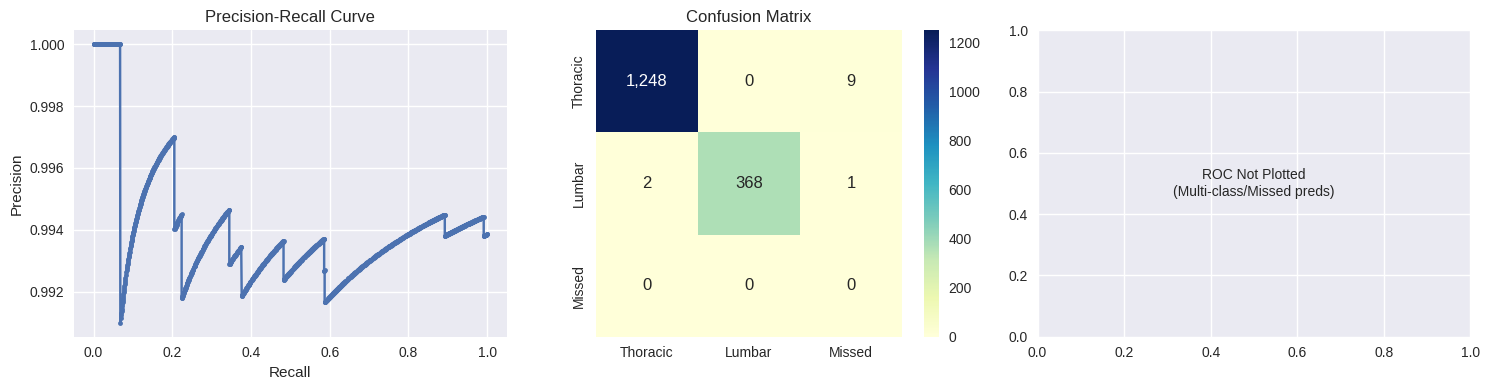

In [7]:
plot_cls_metrics(diou_kfolds_preds, diou_kfolds_targets, best_fold_diou)

In [ ]:
plot_cls_metrics(ciou_kfolds_preds, ciou_kfolds_targets, best_fold_ciou)

              precision    recall  f1-score   support

    Thoracic     1.0000    0.9515    0.9751      1257
      Lumbar     1.0000    0.9757    0.9877       371
      Missed     0.0000    0.0000    0.0000         0

    accuracy                         0.9570      1628
   macro avg     0.6667    0.6424    0.6543      1628
weighted avg     1.0000    0.9570    0.9780      1628

ROC curve not plotted for multi-class/imbalanced scenario (GT unique classes: [0, 1], Pred unique classes: [0, 1, 2]).


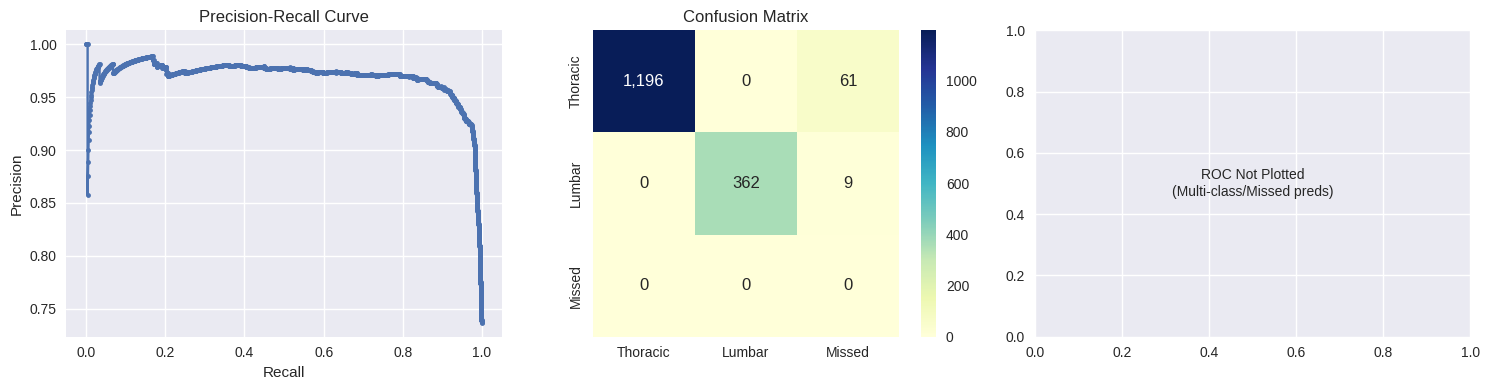

In [8]:
plot_cls_metrics(faster_rcnn_kfolds_preds, faster_rcnn_kfolds_targets, best_fold_faster_rcnn)

# Display Validation Inference

In [9]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)
    # images_dir = Path(config['data']['images_dir'])
    images_dir = Path('./datasets/L8_spinall_full/image')
    processed_height, processed_width = config['preprocessing']['image_size']

[kfolds/splits3.yaml] Val dataset: 62 samples


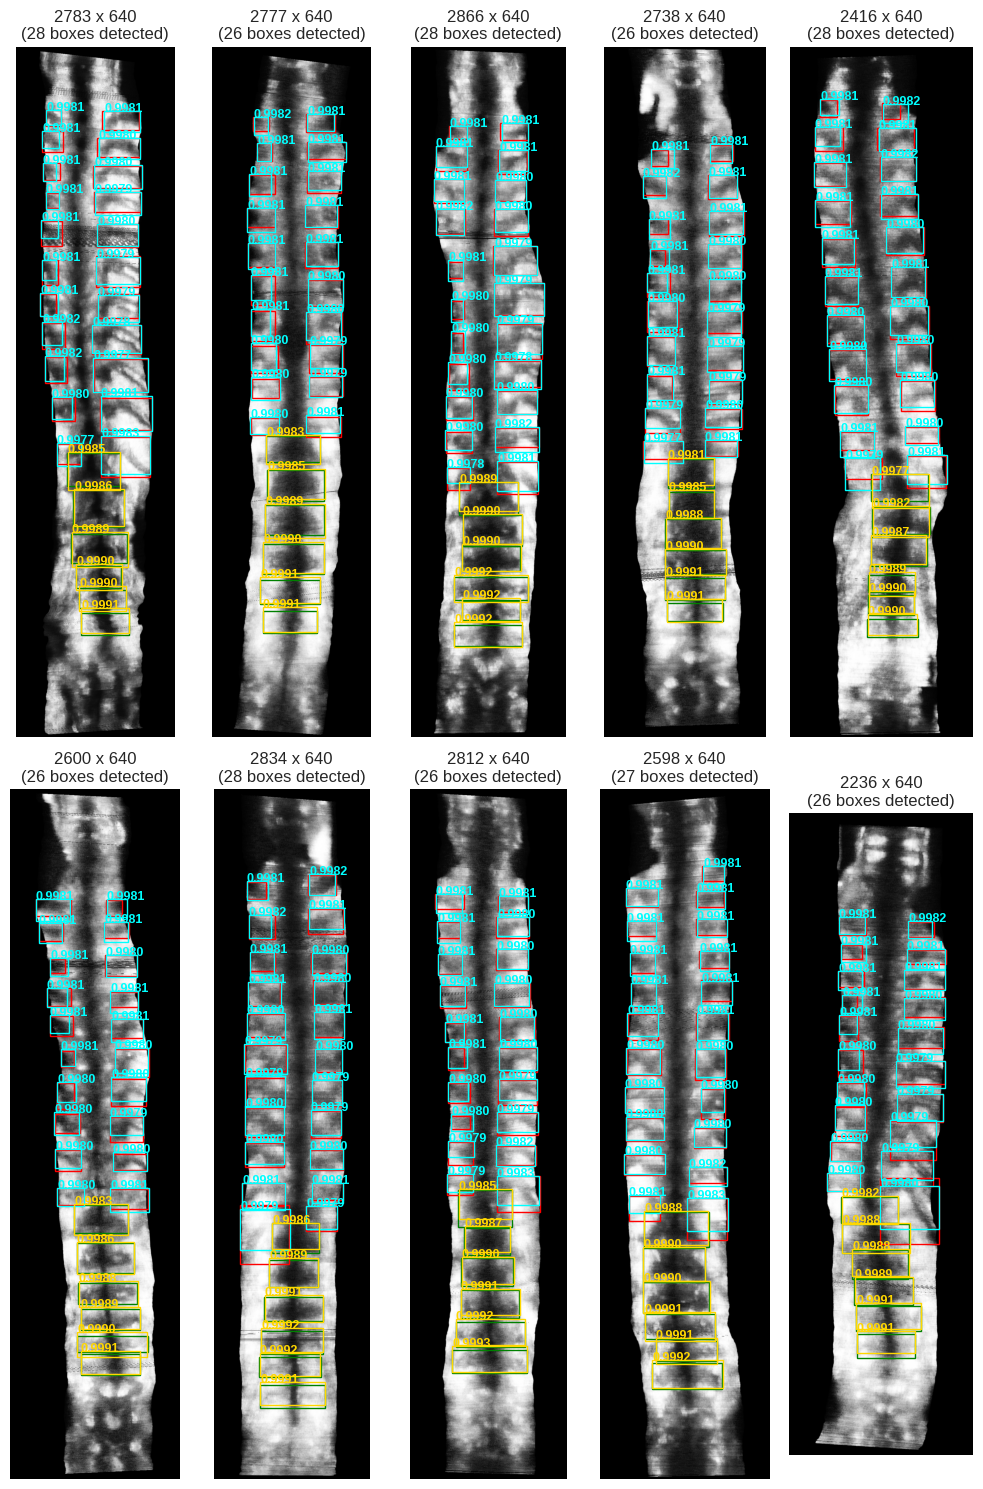

In [10]:
def get_predictions(images, boxes_by_images, all_boxes, all_labels): # Get the number of predicted boxes for each image in the batch
    pred_boxes, pred_labels, pred_scores = model(images, boxes_by_images, all_boxes, all_labels)
    pred_lengths = [len(b) for b in boxes_by_images]
    pred_boxes = torch.cat(pred_boxes, dim=0)
    pred_labels = torch.cat(pred_labels, dim=0)
    pred_scores = torch.cat(pred_scores, dim=0)
    return pred_lengths, pred_boxes, pred_labels, pred_scores

best_fold_idx = int(best_fold_diou.split()[-1]) - 1
model = MultiTaskModel(device=device)
display_validation_inference(model, images_dir, processed_height, processed_width, best_fold_idx, splits_paths, diou_weights, get_predictions, device)

[kfolds/splits3.yaml] Val dataset: 62 samples


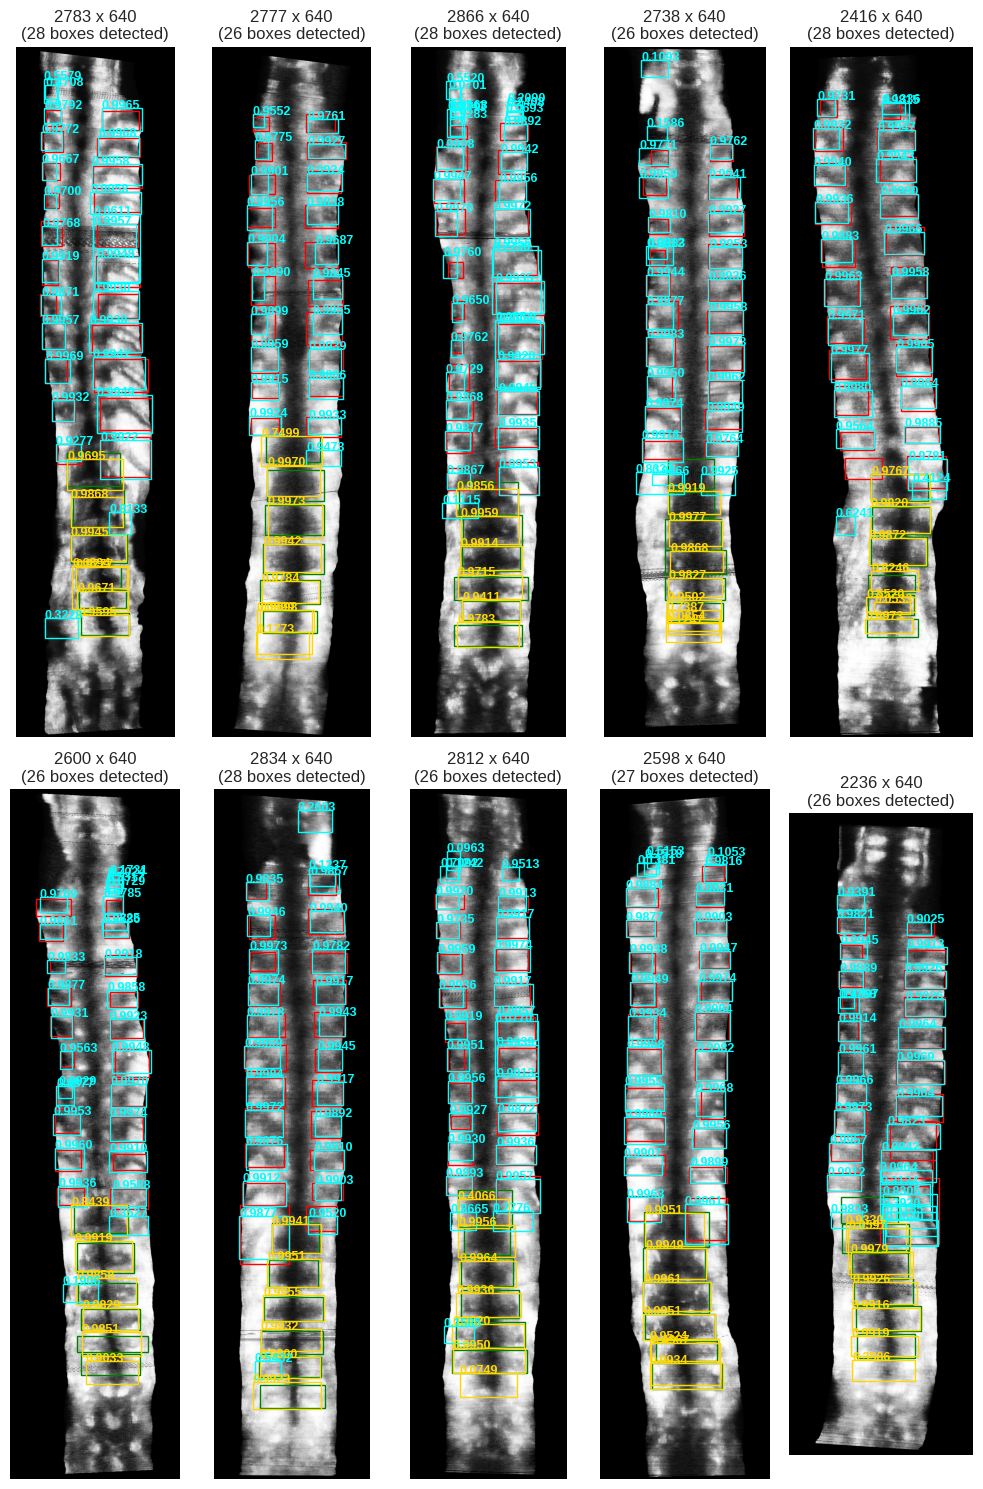

In [11]:
def get_predictions(images, boxes_by_images, all_boxes, all_labels): # Get predictions from Faster R-CNN model
    outputs = model(images)
    pred_lengths, pred_boxes, pred_labels, pred_scores = [], [], [], []
    for output in outputs: # Filter out background class (class 0) and adjust labels
        mask = output['labels'] > 0  # Keep only non-background predictions
        filtered_boxes = output['boxes'][mask]
        filtered_labels = output['labels'][mask] - 1  # Shift labels: 1->0 (Thoracic), 2->1 (Lumbar)
        filtered_scores = output['scores'][mask]
        pred_lengths.append(len(filtered_boxes))
        pred_boxes.append(filtered_boxes)
        pred_labels.append(filtered_labels)
        pred_scores.append(filtered_scores)

    # Convert to tensor
    pred_boxes = torch.cat(pred_boxes, dim=0)
    pred_labels = torch.cat(pred_labels, dim=0)
    pred_scores = torch.cat(pred_scores, dim=0)
    return pred_lengths, pred_boxes, pred_labels, pred_scores

model = FasterRCNN(
    custom_resnet18_backbone(), num_classes=3, # 2 classes (Thoracic, Lumbar) + background
    rpn_anchor_generator=AnchorGenerator(
        sizes=((32, 64, 128, 256, 512),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )
).to(device)

best_fold_idx = int(best_fold_faster_rcnn.split()[-1]) - 1
temp_dataset = ScoliosisDataset(split='train', config_path='config.yaml', splits_path=splits_paths[best_fold_idx], use_bg_class=True)
dataset_mean, dataset_std = temp_dataset.means, temp_dataset.stds

# Update the model's internal transform with the correct mean and std
# Access the transform through model.transform
model.transform.image_mean = dataset_mean.tolist()
model.transform.image_std = dataset_std.tolist()
display_validation_inference(
    model, images_dir, processed_height, processed_width,
    best_fold_idx, splits_paths, faster_rcnn_weights, get_predictions, device
)